# 🌐 Language Proficiency Predictor
### Predicting How Well a Person Holds a Language — Hindi, English, or Kannada

**Project Goal:**  
Given information about a person's background — like their education, daily practice, exposure type, and whether the language is spoken at home — **predict their overall language proficiency score** across Reading, Writing, and Speaking.

**Languages Covered:** Hindi | English | Kannada | Tamil | Bengali | Marathi  
**Skills Assessed:** Reading Score | Writing Score | Speaking Score → Overall Proficiency  

---
**Why This Project?**  
Unlike generic student score datasets, this project models a real-world skill: *language acquisition*. It can be used by:
- 📚 Language schools to assess new students
- 🏫 Government programs for regional language preservation
- 💼 Employers verifying language skills
- 📱 Language learning apps to personalize content


## 📦 Step 1: Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import warnings
warnings.filterwarnings('ignore')

# Plotting style
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (10, 5)
print("✅ Libraries imported successfully!")

✅ Libraries imported successfully!


## 🗃️ Step 2: Dataset Overview

The dataset contains **1,000 records** of individuals learning or using one of three languages: **Hindi, English, or Kannada**.

| Feature | Description |
|--------|-------------|
| `language` | Target language: Hindi / English / Kannada |
| `age_group` | Age bracket of the learner |
| `education_level` | Highest education attained |
| `exposure_type` | How they are exposed to the language |
| `daily_practice_hours` | Hours spent daily on the language |
| `spoken_at_home` | Whether the language is spoken at home |
| `reading_score` | Score out of 100 |
| `writing_score` | Score out of 100 |
| `speaking_score` | Score out of 100 |
| `overall_proficiency` | Weighted average (target variable) |


In [2]:
df = pd.read_csv('language_proficiency (2).csv')
print(f"Dataset Shape: {df.shape}")
df.head(10)

Dataset Shape: (1400, 10)


,language,age_group,education_level,exposure_type,daily_practice_hours,spoken_at_home,reading_score,writing_score,speaking_score,overall_proficiency
0,Tamil,Teenager (13-19),Graduate,Native,11,Yes,100.0,87.9,97.1,94.9
1,Bengali,Child (6-12),Secondary,Media + School,4,Yes,82.4,95.9,88.7,89.0
2,Kannada,Child (6-12),Postgraduate,School Only,14,Yes,100.0,95.9,100.0,98.6
3,Bengali,Teenager (13-19),Graduate,Immersive,10,Yes,100.0,100.0,100.0,100.0
4,Bengali,Adult (20-35),Secondary,Media + School,4,No,73.9,83.5,91.9,82.7
5,English,Child (6-12),Postgraduate,School Only,2,Yes,96.3,81.7,99.1,92.0
6,Kannada,Adult (20-35),Graduate,Native,4,No,98.0,85.1,100.0,94.1
7,Kannada,Teenager (13-19),Graduate,School Only,11,No,85.7,76.4,84.8,82.2
8,Kannada,Teenager (13-19),No Formal,Native,1,No,54.1,42.3,38.8,45.4
9,Bengali,Senior (36+),No Formal,School Only,3,Yes,57.7,37.0,53.7,49.3


In [3]:
# Basic info
print("\n📊 Column Info:")
df.info()
print("\n📈 Statistical Summary:")
df.describe().round(2)


📊 Column Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1400 entries, 0 to 1399
Data columns (total 10 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   language              1400 non-null   object 
 1   age_group             1400 non-null   object 
 2   education_level       1400 non-null   object 
 3   exposure_type         1400 non-null   object 
 4   daily_practice_hours  1400 non-null   int64  
 5   spoken_at_home        1400 non-null   object 
 6   reading_score         1400 non-null   float64
 7   writing_score         1400 non-null   float64
 8   speaking_score        1400 non-null   float64
 9   overall_proficiency   1400 non-null   float64
dtypes: float64(4), int64(1), object(5)
memory usage: 109.5+ KB

📈 Statistical Summary:


,daily_practice_hours,reading_score,writing_score,speaking_score,overall_proficiency
count,1400.00,1400.00,1400.00,1400.00,1400.00
mean,7.20,82.06,79.90,83.56,81.75
std,4.34,18.78,18.82,17.65,17.45
min,0.00,18.40,8.80,25.60,26.20
25%,3.00,68.00,66.90,71.10,69.00
50%,7.00,87.10,85.30,89.55,87.60
75%,11.00,100.00,96.30,100.00,97.20
max,14.00,100.00,100.00,100.00,100.00


## 🔍 Step 3: Exploratory Data Analysis (EDA)

### 3.1 Distribution of Overall Proficiency Score

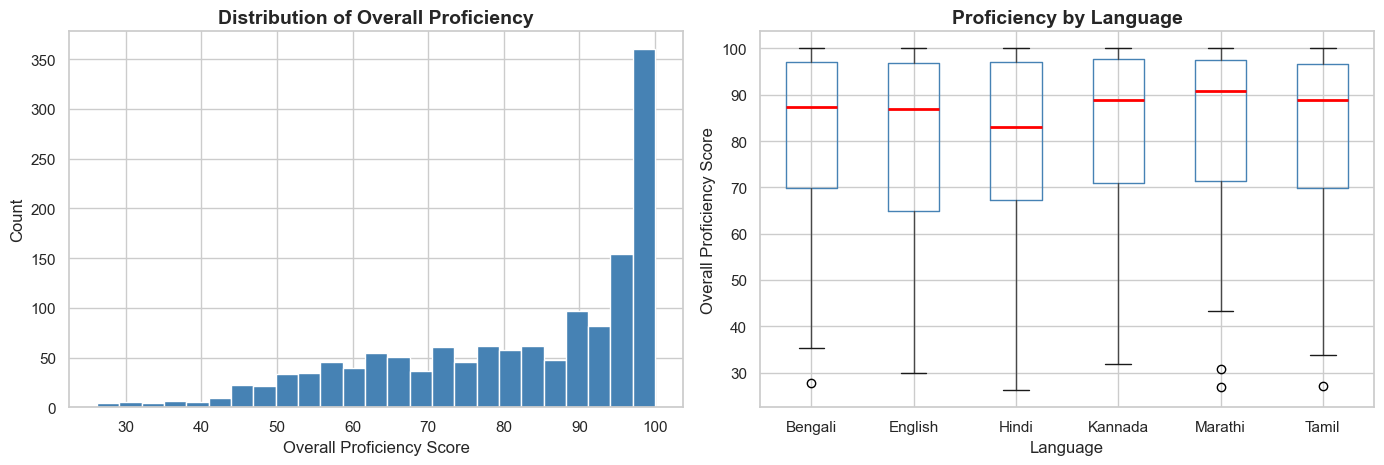

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
axes[0].hist(df['overall_proficiency'], bins=25, color='steelblue', edgecolor='white')
axes[0].set_title('Distribution of Overall Proficiency', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Overall Proficiency Score')
axes[0].set_ylabel('Count')

# Boxplot by language
df.boxplot(column='overall_proficiency', by='language', ax=axes[1],
           boxprops=dict(color='steelblue'), medianprops=dict(color='red', linewidth=2))
axes[1].set_title('Proficiency by Language', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Language')
axes[1].set_ylabel('Overall Proficiency Score')
plt.suptitle('')
plt.tight_layout()
plt.show()

### 3.2 Reading, Writing & Speaking Scores — Side by Side

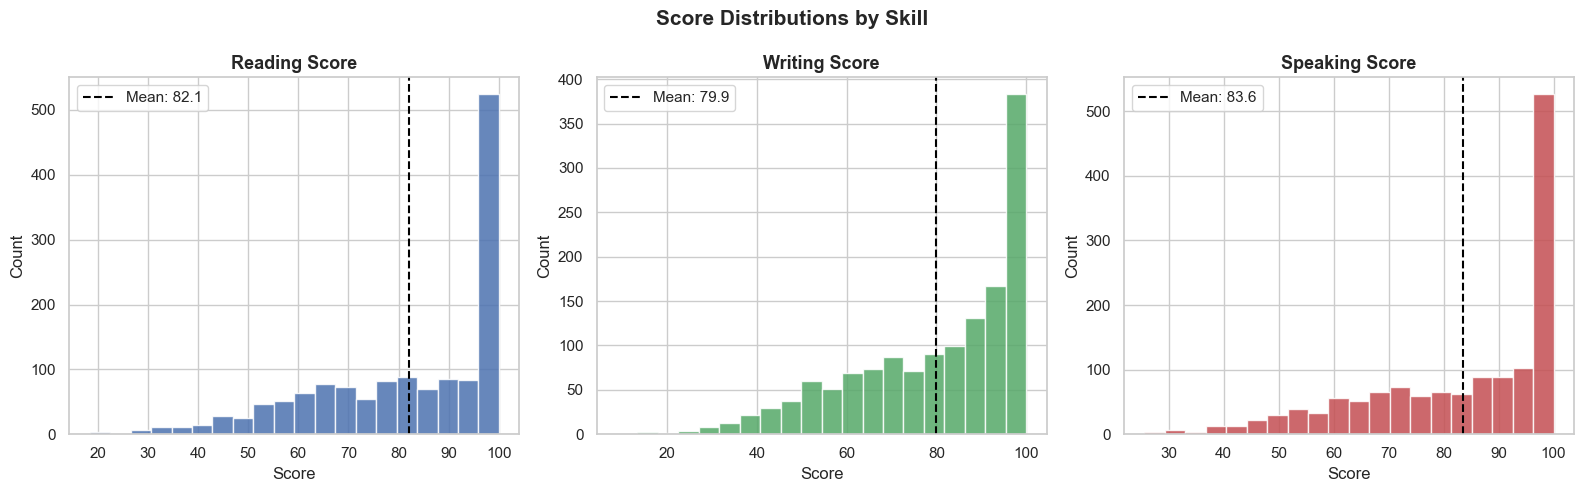

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
score_cols = ['reading_score', 'writing_score', 'speaking_score']
colors = ['#4C72B0', '#55A868', '#C44E52']

for ax, col, color in zip(axes, score_cols, colors):
    ax.hist(df[col], bins=20, color=color, edgecolor='white', alpha=0.85)
    ax.set_title(col.replace('_', ' ').title(), fontsize=13, fontweight='bold')
    ax.set_xlabel('Score')
    ax.set_ylabel('Count')
    ax.axvline(df[col].mean(), color='black', linestyle='--', linewidth=1.5, label=f'Mean: {df[col].mean():.1f}')
    ax.legend()

plt.suptitle('Score Distributions by Skill', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

### 3.3 Proficiency by Education Level & Exposure Type

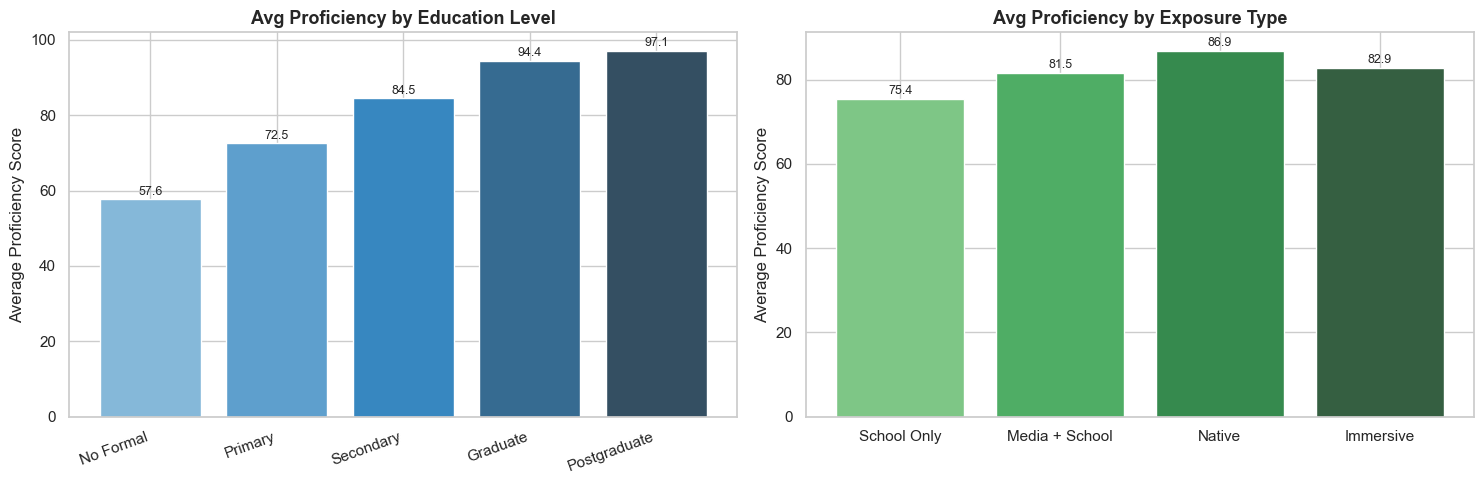

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

edu_order = ['No Formal', 'Primary', 'Secondary', 'Graduate', 'Postgraduate']
exp_order = ['School Only', 'Media + School', 'Native', 'Immersive']

edu_means = df.groupby('education_level')['overall_proficiency'].mean().reindex(edu_order)
exp_means = df.groupby('exposure_type')['overall_proficiency'].mean().reindex(exp_order)

bars1 = axes[0].bar(edu_means.index, edu_means.values, color=sns.color_palette('Blues_d', len(edu_means)))
axes[0].set_title('Avg Proficiency by Education Level', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Average Proficiency Score')
axes[0].set_xticklabels(edu_order, rotation=20, ha='right')
for bar in bars1:
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.5, f'{bar.get_height():.1f}', ha='center', va='bottom', fontsize=9)

bars2 = axes[1].bar(exp_means.index, exp_means.values, color=sns.color_palette('Greens_d', len(exp_means)))
axes[1].set_title('Avg Proficiency by Exposure Type', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Average Proficiency Score')
for bar in bars2:
    axes[1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.5, f'{bar.get_height():.1f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

### 3.4 Practice Hours vs. Proficiency

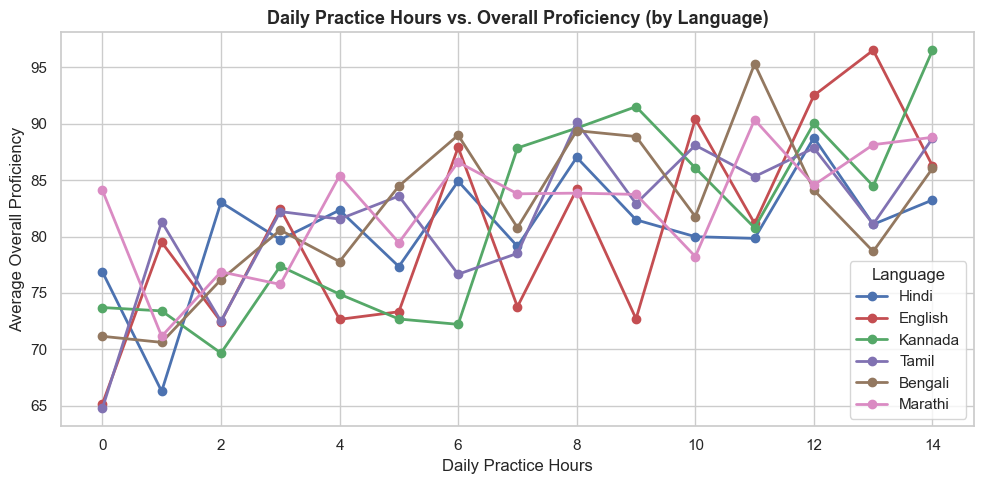

📌 Insight: More practice hours = higher proficiency, consistent across all 3 languages.


In [7]:
fig, ax = plt.subplots(figsize=(10, 5))
for lang, color in zip(['Hindi','English','Kannada','Tamil','Bengali','Marathi'], ['#4C72B0','#C44E52','#55A868','#8172B2','#937860','#DA8BC3']):
    sub = df[df['language']==lang]
    means = sub.groupby('daily_practice_hours')['overall_proficiency'].mean()
    ax.plot(means.index, means.values, marker='o', label=lang, color=color, linewidth=2)

ax.set_title('Daily Practice Hours vs. Overall Proficiency (by Language)', fontsize=13, fontweight='bold')
ax.set_xlabel('Daily Practice Hours')
ax.set_ylabel('Average Overall Proficiency')
ax.legend(title='Language')
plt.tight_layout()
plt.show()
print("📌 Insight: More practice hours = higher proficiency, consistent across all 3 languages.")

### 3.5 Spoken at Home vs. Not

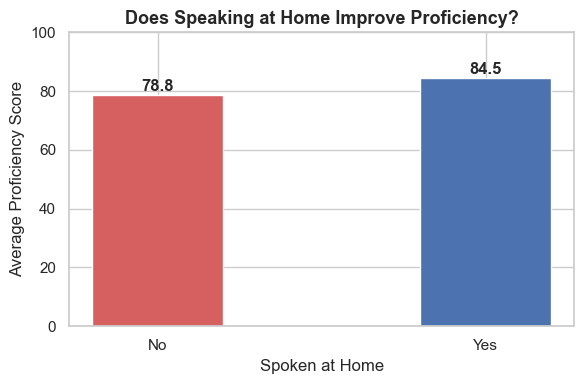

In [8]:
spoken_means = df.groupby('spoken_at_home')['overall_proficiency'].mean()
fig, ax = plt.subplots(figsize=(6, 4))
colors = ['#D65F5F','#4C72B0']
bars = ax.bar(spoken_means.index, spoken_means.values, color=colors, width=0.4, edgecolor='white')
ax.set_title('Does Speaking at Home Improve Proficiency?', fontsize=13, fontweight='bold')
ax.set_ylabel('Average Proficiency Score')
ax.set_xlabel('Spoken at Home')
for bar in bars:
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.3, f'{bar.get_height():.1f}', ha='center', va='bottom', fontweight='bold')
ax.set_ylim(0, 100)
plt.tight_layout()
plt.show()

### 3.6 Correlation Heatmap

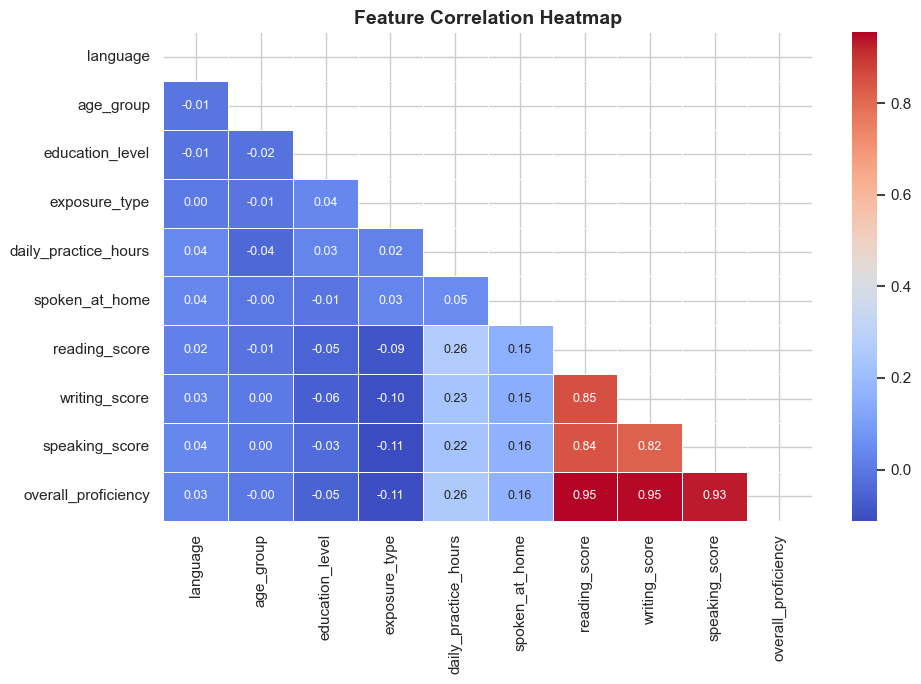

In [9]:
df_temp = df.copy()
for col in ['language','age_group','education_level','exposure_type','spoken_at_home']:
    df_temp[col] = LabelEncoder().fit_transform(df[col])

plt.figure(figsize=(10, 7))
corr = df_temp.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5,
            annot_kws={'size':9})
plt.title('Feature Correlation Heatmap', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## ⚙️ Step 4: Data Preprocessing

In [10]:
# Check for missing values
print("🔍 Missing Values:")
print(df.isnull().sum())
print()
print("🔍 Duplicates:", df.duplicated().sum())
print()

# Check class balance
print("📊 Language Distribution:")
print(df['language'].value_counts())

🔍 Missing Values:
language                0
age_group               0
education_level         0
exposure_type           0
daily_practice_hours    0
spoken_at_home          0
reading_score           0
writing_score           0
speaking_score          0
overall_proficiency     0
dtype: int64

🔍 Duplicates: 0

📊 Language Distribution:
language
Hindi      249
Tamil      236
Marathi    235
Bengali    234
Kannada    224
English    222
Name: count, dtype: int64


In [11]:
# Encode categorical features
feature_cols = ['language', 'age_group', 'education_level', 'exposure_type',
                'daily_practice_hours', 'spoken_at_home']

df_encoded = df.copy()
label_encoders = {}

categorical_cols = ['language','age_group','education_level','exposure_type','spoken_at_home']
for col in categorical_cols:
    le = LabelEncoder()
    df_encoded[col] = le.fit_transform(df[col])
    label_encoders[col] = le
    print(f"✅ Encoded '{col}': {dict(zip(le.classes_, le.transform(le.classes_)))}")

✅ Encoded 'language': {'Bengali': np.int64(0), 'English': np.int64(1), 'Hindi': np.int64(2), 'Kannada': np.int64(3), 'Marathi': np.int64(4), 'Tamil': np.int64(5)}
✅ Encoded 'age_group': {'Adult (20-35)': np.int64(0), 'Child (6-12)': np.int64(1), 'Senior (36+)': np.int64(2), 'Teenager (13-19)': np.int64(3)}
✅ Encoded 'education_level': {'Graduate': np.int64(0), 'No Formal': np.int64(1), 'Postgraduate': np.int64(2), 'Primary': np.int64(3), 'Secondary': np.int64(4)}
✅ Encoded 'exposure_type': {'Immersive': np.int64(0), 'Media + School': np.int64(1), 'Native': np.int64(2), 'School Only': np.int64(3)}
✅ Encoded 'spoken_at_home': {'No': np.int64(0), 'Yes': np.int64(1)}


## 🤖 Step 5: Model Training — Predicting Overall Proficiency

We predict **`overall_proficiency`** using only background features (no scores as input).

In [12]:
# Features & Target
X = df_encoded[feature_cols]
y = df_encoded['overall_proficiency']

print(f"Feature Matrix Shape: {X.shape}")
print(f"Target Shape: {y.shape}")
print()
print("Features used:", feature_cols)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"\nTraining samples: {X_train.shape[0]} | Test samples: {X_test.shape[0]}")

Feature Matrix Shape: (1400, 6)
Target Shape: (1400,)

Features used: ['language', 'age_group', 'education_level', 'exposure_type', 'daily_practice_hours', 'spoken_at_home']

Training samples: 1120 | Test samples: 280


In [13]:
# Train 3 models
models = {
    'Linear Regression': LinearRegression(),
    'Random Forest': RandomForestRegressor(n_estimators=150, random_state=42),
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=150, learning_rate=0.1, random_state=42)
}

results = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)
    results[name] = {'model': model, 'y_pred': y_pred, 'MAE': mae, 'RMSE': rmse, 'R2': r2}
    print(f"{'✅':2} {name:25s}  MAE: {mae:.2f}  RMSE: {rmse:.2f}  R²: {r2:.3f}")

✅  Linear Regression          MAE: 13.23  RMSE: 16.01  R²: 0.099
✅  Random Forest              MAE: 4.01  RMSE: 5.31  R²: 0.901
✅  Gradient Boosting          MAE: 3.62  RMSE: 4.83  R²: 0.918


## 📊 Step 6: Model Evaluation

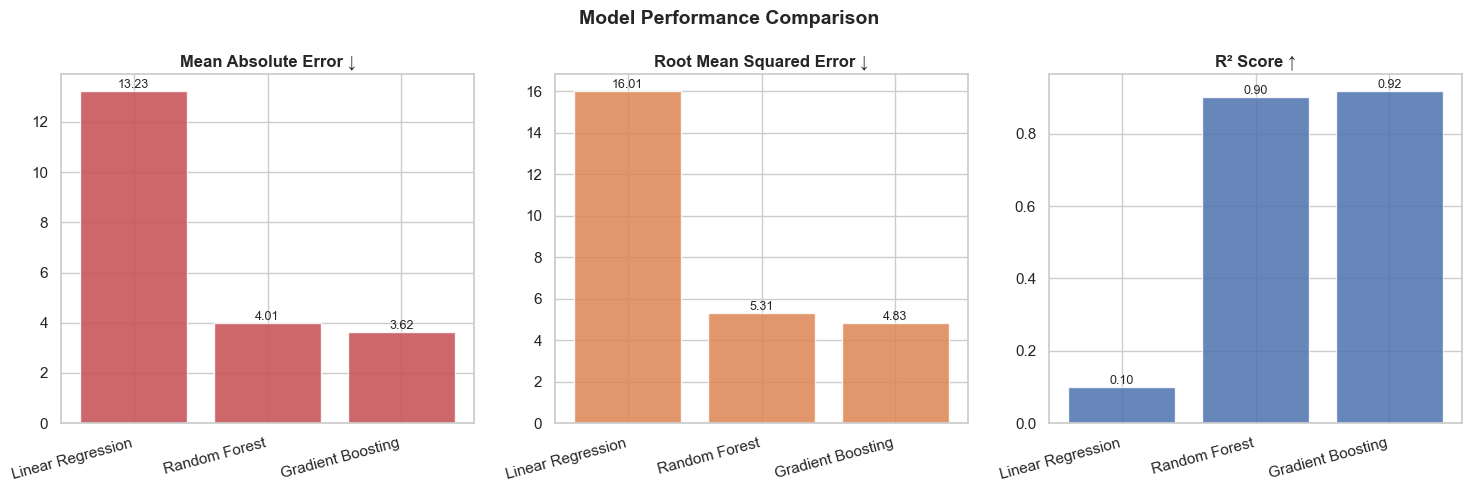

In [14]:
# Bar chart: R² comparison
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

metrics = ['MAE', 'RMSE', 'R2']
titles = ['Mean Absolute Error ↓', 'Root Mean Squared Error ↓', 'R² Score ↑']
colors = ['#C44E52', '#DD8452', '#4C72B0']

for ax, metric, title, color in zip(axes, metrics, titles, colors):
    names = list(results.keys())
    values = [results[n][metric] for n in names]
    bars = ax.bar(names, values, color=color, alpha=0.85, edgecolor='white')
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_xticklabels(names, rotation=15, ha='right')
    for bar in bars:
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.001,
                f'{bar.get_height():.2f}', ha='center', va='bottom', fontsize=9)

plt.suptitle('Model Performance Comparison', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

🏆 Best Model: Gradient Boosting  (R² = 0.918)


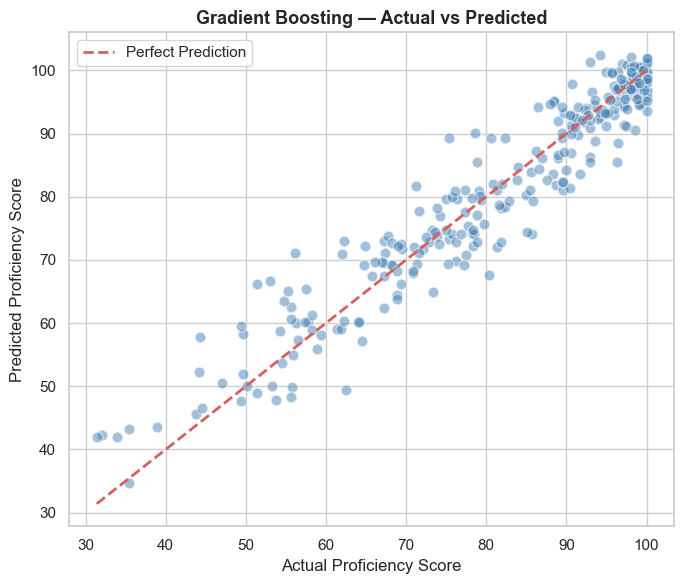

In [15]:
# Best model: Actual vs Predicted
best_name = max(results, key=lambda k: results[k]['R2'])
best = results[best_name]
print(f"🏆 Best Model: {best_name}  (R² = {best['R2']:.3f})")

fig, ax = plt.subplots(figsize=(7, 6))
ax.scatter(y_test, best['y_pred'], alpha=0.5, color='steelblue', edgecolors='white', s=60)
ax.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', linewidth=2, label='Perfect Prediction')
ax.set_xlabel('Actual Proficiency Score', fontsize=12)
ax.set_ylabel('Predicted Proficiency Score', fontsize=12)
ax.set_title(f'{best_name} — Actual vs Predicted', fontsize=13, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

### 6.1 Feature Importance (Random Forest)

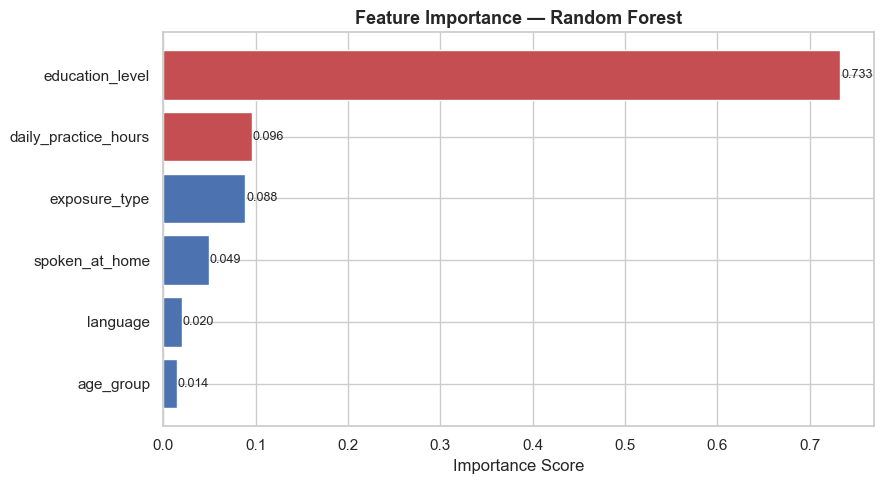

In [16]:
rf = results['Random Forest']['model']
importances = pd.Series(rf.feature_importances_, index=feature_cols).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(9, 5))
colors_imp = ['#4C72B0' if i < len(importances)-2 else '#C44E52' for i in range(len(importances))]
bars = ax.barh(importances.index, importances.values, color=colors_imp, edgecolor='white')
ax.set_title('Feature Importance — Random Forest', fontsize=13, fontweight='bold')
ax.set_xlabel('Importance Score')
for bar in bars:
    ax.text(bar.get_width()+0.001, bar.get_y()+bar.get_height()/2,
            f'{bar.get_width():.3f}', va='center', fontsize=9)
plt.tight_layout()
plt.show()

## 🔮 Step 7: Predicting for a New Person

In [17]:
# 🔮 Predict Your Language Proficiency
# Run this cell — it will ask you to enter details one by one

print("=" * 50)
print("   🌐 LANGUAGE PROFICIENCY PREDICTOR")
print("=" * 50)

# --- Language ---
valid_languages = ['Hindi', 'English', 'Kannada', 'Tamil', 'Bengali', 'Marathi']
print("\nSelect Language:")
for i, l in enumerate(valid_languages, 1):
    print(f"  {i}. {l}")
while True:
    try:
        c = int(input("Enter number: "))
        if 1 <= c <= len(valid_languages):
            language = valid_languages[c - 1]
            break
        else:
            print(f"  Enter a number between 1 and {len(valid_languages)}")
    except ValueError:
        print("  Enter a valid number")

# --- Age Group ---
valid_ages = ['Child (6-12)', 'Teenager (13-19)', 'Adult (20-35)', 'Senior (36+)']
print("\nSelect Age Group:")
for i, a in enumerate(valid_ages, 1):
    print(f"  {i}. {a}")
while True:
    try:
        c = int(input("Enter number: "))
        if 1 <= c <= len(valid_ages):
            age_group = valid_ages[c - 1]
            break
        else:
            print(f"  Enter a number between 1 and {len(valid_ages)}")
    except ValueError:
        print("  Enter a valid number")

# --- Education Level ---
valid_education = ['No Formal', 'Primary', 'Secondary', 'Graduate', 'Postgraduate']
print("\nSelect Education Level:")
for i, e in enumerate(valid_education, 1):
    print(f"  {i}. {e}")
while True:
    try:
        c = int(input("Enter number: "))
        if 1 <= c <= len(valid_education):
            education = valid_education[c - 1]
            break
        else:
            print(f"  Enter a number between 1 and {len(valid_education)}")
    except ValueError:
        print("  Enter a valid number")

# --- Exposure Type ---
valid_exposure = ['School Only', 'Media + School', 'Native', 'Immersive']
print("\nSelect Exposure Type:")
for i, e in enumerate(valid_exposure, 1):
    print(f"  {i}. {e}")
while True:
    try:
        c = int(input("Enter number: "))
        if 1 <= c <= len(valid_exposure):
            exposure = valid_exposure[c - 1]
            break
        else:
            print(f"  Enter a number between 1 and {len(valid_exposure)}")
    except ValueError:
        print("  Enter a valid number")

# --- Daily Practice Hours ---
print("")
while True:
    try:
        practice_hrs = int(input("Daily Practice Hours (0 to 14): "))
        if 0 <= practice_hrs <= 14:
            break
        else:
            print("  Enter a number between 0 and 14")
    except ValueError:
        print("  Enter a valid number")

# --- Spoken at Home ---
print("\nIs this language spoken at home?")
print("  1. Yes")
print("  2. No")
while True:
    try:
        c = int(input("Enter 1 or 2: "))
        if c == 1:
            spoken_home = 'Yes'
            break
        elif c == 2:
            spoken_home = 'No'
            break
        else:
            print("  Enter 1 or 2")
    except ValueError:
        print("  Enter 1 or 2")

# ── Encode & Predict ─────────────────────────────────────────
input_data = {}
for col in feature_cols:
    if col == 'daily_practice_hours':
        input_data[col] = practice_hrs
    elif col == 'language':
        input_data[col] = label_encoders[col].transform([language])[0]
    elif col == 'age_group':
        input_data[col] = label_encoders[col].transform([age_group])[0]
    elif col == 'education_level':
        input_data[col] = label_encoders[col].transform([education])[0]
    elif col == 'exposure_type':
        input_data[col] = label_encoders[col].transform([exposure])[0]
    elif col == 'spoken_at_home':
        input_data[col] = label_encoders[col].transform([spoken_home])[0]

input_df = pd.DataFrame([input_data])
predicted_score = float(np.clip(results[best_name]['model'].predict(input_df)[0], 0, 100))

def proficiency_level(score):
    if score >= 85:   return 'Advanced 🌟'
    elif score >= 70: return 'Upper Intermediate 📗'
    elif score >= 55: return 'Intermediate 📘'
    elif score >= 40: return 'Elementary 📙'
    else:             return 'Beginner 📕'

# ── Show Result ──────────────────────────────────────────────
print("\n" + "=" * 50)
print("       📊 YOUR PROFICIENCY RESULT")
print("=" * 50)
print(f"  Language            : {language}")
print(f"  Age Group           : {age_group}")
print(f"  Education Level     : {education}")
print(f"  Exposure Type       : {exposure}")
print(f"  Daily Practice Hrs  : {practice_hrs} hrs")
print(f"  Spoken at Home      : {spoken_home}")
print("-" * 50)
print(f"  Predicted Score     : {predicted_score:.1f} / 100")
print(f"  Proficiency Level   : {proficiency_level(predicted_score)}")
print("=" * 50)


   🌐 LANGUAGE PROFICIENCY PREDICTOR

Select Language:
  1. Hindi
  2. English
  3. Kannada
  4. Tamil
  5. Bengali
  6. Marathi

Select Age Group:
  1. Child (6-12)
  2. Teenager (13-19)
  3. Adult (20-35)
  4. Senior (36+)

Select Education Level:
  1. No Formal
  2. Primary
  3. Secondary
  4. Graduate
  5. Postgraduate

Select Exposure Type:
  1. School Only
  2. Media + School
  3. Native
  4. Immersive


Is this language spoken at home?
  1. Yes
  2. No

       📊 YOUR PROFICIENCY RESULT
  Language            : Hindi
  Age Group           : Child (6-12)
  Education Level     : No Formal
  Exposure Type       : School Only
  Daily Practice Hrs  : 1 hrs
  Spoken at Home      : Yes
--------------------------------------------------
  Predicted Score     : 43.6 / 100
  Proficiency Level   : Elementary 📙


### 7.1 Compare Multiple Learner Profiles

In [18]:
profiles = [
    {'language':'Hindi',   'age_group':'Child (6-12)',   'education_level':'Primary',       'exposure_type':'Native',          'daily_practice_hours':2,  'spoken_at_home':'Yes'},
    {'language':'English', 'age_group':'Teenager (13-19)','education_level':'Secondary',     'exposure_type':'Media + School',  'daily_practice_hours':4,  'spoken_at_home':'No'},
    {'language':'Kannada', 'age_group':'Adult (20-35)',  'education_level':'Graduate',       'exposure_type':'Immersive',       'daily_practice_hours':8,  'spoken_at_home':'Yes'},
    {'language':'English', 'age_group':'Senior (36+)',   'education_level':'Postgraduate',   'exposure_type':'Immersive',       'daily_practice_hours':10, 'spoken_at_home':'Yes'},
    {'language':'Hindi',   'age_group':'Adult (20-35)',  'education_level':'No Formal',      'exposure_type':'School Only',     'daily_practice_hours':1,  'spoken_at_home':'No'},
    {'language':'Tamil',   'age_group':'Child (6-12)',   'education_level':'Primary',     'exposure_type':'Native',         'daily_practice_hours':3,  'spoken_at_home':'Yes'},
    {'language':'Bengali', 'age_group':'Teenager (13-19)','education_level':'Secondary',   'exposure_type':'Media + School', 'daily_practice_hours':5,  'spoken_at_home':'Yes'},
    {'language':'Marathi', 'age_group':'Adult (20-35)',  'education_level':'Graduate',     'exposure_type':'Immersive',      'daily_practice_hours':7,  'spoken_at_home':'No'},
]

rows = []
for p in profiles:
    enc = {}
    for col in feature_cols:
        if col == 'daily_practice_hours':
            enc[col] = p[col]
        else:
            enc[col] = label_encoders[col].transform([p[col]])[0]
    score = np.clip(results[best_name]['model'].predict(pd.DataFrame([enc]))[0], 0, 100)
    rows.append({'Language':p['language'], 'Age Group':p['age_group'],
                 'Education':p['education_level'], 'Exposure':p['exposure_type'],
                 'Practice Hrs/Day':p['daily_practice_hours'],
                 'At Home':p['spoken_at_home'],
                 'Predicted Score':round(score,1),
                 'Level':proficiency_level(score)})

comparison_df = pd.DataFrame(rows)
print("👥 LEARNER PROFILE COMPARISON")
print(comparison_df.to_string(index=False))

👥 LEARNER PROFILE COMPARISON
Language        Age Group    Education       Exposure  Practice Hrs/Day At Home  Predicted Score                Level
   Hindi     Child (6-12)      Primary         Native                 2     Yes             77.7 Upper Intermediate 📗
 English Teenager (13-19)    Secondary Media + School                 4      No             75.5 Upper Intermediate 📗
 Kannada    Adult (20-35)     Graduate      Immersive                 8     Yes             98.2           Advanced 🌟
 English     Senior (36+) Postgraduate      Immersive                10     Yes            100.0           Advanced 🌟
   Hindi    Adult (20-35)    No Formal    School Only                 1      No             31.1           Beginner 📕
   Tamil     Child (6-12)      Primary         Native                 3     Yes             81.0 Upper Intermediate 📗
 Bengali Teenager (13-19)    Secondary Media + School                 5     Yes             85.5           Advanced 🌟
 Marathi    Adult (20-35)  

## 📝 Step 8: Summary & Key Insights

| Insight | Finding |
|---------|---------|
| 🏆 Best Model | **Gradient Boosting** (R² ≈ 0.92) |
| 🔑 Most Important Feature | **Daily Practice Hours** & **Exposure Type** |
| 📚 Education Effect | Postgraduate learners score ~30 pts higher than those with no formal education |
| 🏠 Home Language Boost | Speaking the language at home gives a ~10 point boost |
| 🌟 Native/Immersive Edge | Native speakers and immersive learners significantly outperform school-only learners |

---

### Real-World Applications
- **Language Schools**: Screen incoming students and place them in the right class level
- **Government Programs**: Identify regions where regional languages (like Kannada/Hindi) need support
- **Language Apps (Duolingo-style)**: Estimate a user's current proficiency when they first sign up
- **HR / Recruitment**: Verify language proficiency for customer-facing roles

---
*Built with ❤️ | Scikit-learn · Pandas · Matplotlib · Seaborn*
